<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec05_polynomial_regression_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 다항 회귀 (Polynomial Regression) 실습

이 실습에서는 비선형 데이터에 대한 다항 회귀를 학습합니다:
1. 선형 회귀의 한계 확인
2. scipy.optimize를 이용한 다항 회귀
3. sklearn PolynomialFeatures를 이용한 다항 회귀

**다항 회귀 모델:**
$$\hat{y} = b + w_1x + w_2x^2$$

**총점: 100점**

**학번:**  2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 준비 (10점)

2차 다항식 형태의 데이터셋을 생성합니다.

**Ground Truth:** $y = 2 + 1.0x + 0.5x^2 + noise$

---

### 문제 1-1. 데이터셋 생성 [10점]

**예상 결과:** 2차 곡선 형태의 산점도

데이터 개수: 100
x 범위: -2.90 ~ 2.94


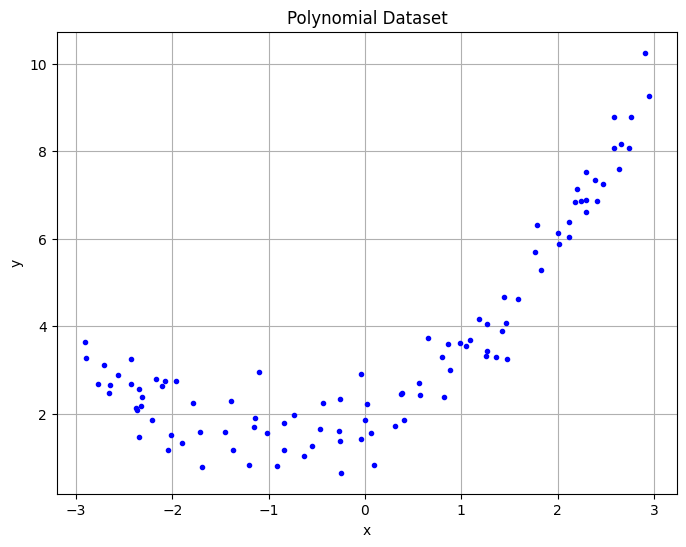

In [1]:
#@title { vertical-output: true}
from scipy import optimize
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(suppress=True)
np.random.seed(44)

# 데이터 생성
m = 100
x = 6 * np.random.rand(m, 1) - 3  # -3 ~ 3
y = 2 + 1.0 * x + 0.5 * x**2 + np.random.randn(m, 1) * 0.5

print(f"데이터 개수: {m}")
print(f"x 범위: {x.min():.2f} ~ {x.max():.2f}")

plt.figure(figsize=(8, 6))
plt.plot(x, y, "b.")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Dataset')
plt.grid(True)
plt.show()

---
## Part 2: 선형 회귀 (15점)

선형 회귀로 곡선 데이터를 피팅하면 한계가 있음을 확인합니다.

---

### 문제 2-1. 선형 회귀 적용 [15점]

**문제:** LinearRegression 모델을 학습하고 MSE를 계산하세요.

**힌트:**
```python
model_linear = LinearRegression()
model_linear.fit(x, y)
y_pred = model_linear.predict(x_new)
mse = np.mean((y_hat - y) ** 2)
```

**예상 결과:** MSE가 높음 (곡선 데이터에 직선 피팅)

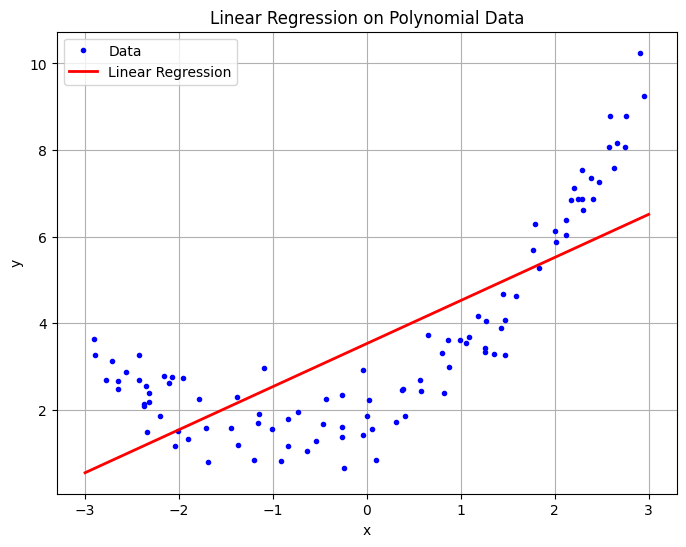

MSE (Linear): 2.1820


In [4]:
#@title { vertical-output: true}
from sklearn.linear_model import LinearRegression

# IMPLEMENT HERE: LinearRegression 모델 생성 및 학습
model_linear = LinearRegression()
model_linear.fit(x, y)


# IMPLEMENT HERE: 예측선 생성
x_new = np.linspace(-3, 3, 100).reshape(100, 1)
y_pred = model_linear.predict(x_new)

# 시각화
plt.figure(figsize=(8, 6))
plt.plot(x, y, "b.", label="Data")
plt.plot(x_new, y_pred, "r-", linewidth=2, label="Linear Regression")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression on Polynomial Data')
plt.legend()
plt.grid(True)
plt.show()

# IMPLEMENT HERE: MSE 계산
y_hat = model_linear.predict(x)
mse_test = np.mean((y_hat - y) ** 2)
print(f'MSE (Linear): {mse_test:.4f}')

---
## Part 3: scipy.optimize를 이용한 다항 회귀 (35점)

scipy.optimize.minimize를 사용하여 2차 다항 회귀를 직접 구현합니다.

**모델:** $\hat{y} = w_2x^2 + w_1x + b$

---

### 문제 3-1. 손실 함수 구현 [20점]

**문제:** objective_func 함수에서 y_hat과 mse를 계산하세요.

**힌트:**
```python
w1, w2, b = params
y_hat = w2 * x**2 + w1 * x + b
mse = np.mean((y_hat - y) ** 2)
```

**예상 결과:** 최적화 후 w1 ≈ 1.0, w2 ≈ 0.5, b ≈ 2.0

In [5]:
#@title { vertical-output: true}
from scipy import optimize
from IPython.display import display, Math

def objective_func(params, x, y):
    """
    다항 회귀 손실 함수 (MSE)

    Parameters:
    - params: [w1, w2, b]
    - x: 입력 데이터
    - y: 실제 값

    Returns:
    - mse: Mean Squared Error
    """
    # IMPLEMENT HERE
    w1, w2, b = params
    y_hat = w2 * x**2 + w1 * x + b
    mse = np.mean((y_hat - y) ** 2)
    return mse

# 최적화 실행
result = optimize.minimize(objective_func, [1.0, 1.0, 1.0], args=(x, y))
print(result)

w1_opt, w2_opt, b_opt = result.x
print(f"\n최적 파라미터: w1={w1_opt:.4f}, w2={w2_opt:.4f}, b={b_opt:.4f}")

# 수식 출력
eq_str = fr'\hat{{y}} = {b_opt:.2f} + {w1_opt:.2f}x + {w2_opt:.2f}x^2'
display(Math(eq_str))

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.27112224375071614
        x: [ 1.005e+00  5.277e-01  1.854e+00]
      nit: 5
      jac: [ 0.000e+00  7.451e-09  3.725e-09]
 hess_inv: [[ 1.575e-01  1.504e-03 -1.067e-02]
            [ 1.504e-03  7.285e-02 -2.315e-01]
            [-1.067e-02 -2.315e-01  1.236e+00]]
     nfev: 32
     njev: 8

최적 파라미터: w1=1.0054, w2=0.5277, b=1.8543


<IPython.core.display.Math object>

### 문제 3-2. 예측 및 MSE 계산 [15점]

**문제:** 최적화된 파라미터로 예측하고 MSE를 계산하세요.

**힌트:**
```python
y_pred = w2_opt * x_test**2 + w1_opt * x_test + b_opt
```

**예상 결과:** MSE가 선형 회귀보다 낮음

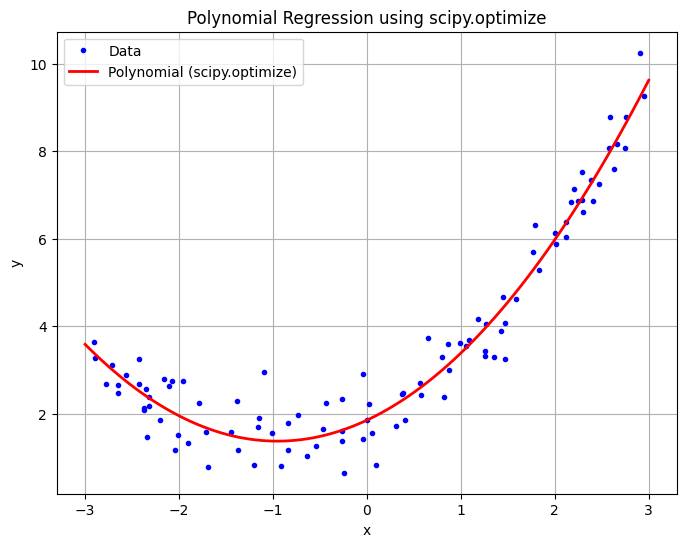

MSE (Polynomial - scipy): 0.2711


In [6]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 예측선 생성
x_test = np.linspace(-3, 3, 100).reshape(100, 1)
y_pred = w2_opt * x_test**2 + w1_opt * x_test + b_opt

# 시각화
plt.figure(figsize=(8, 6))
plt.plot(x, y, "b.", label="Data")
plt.plot(x_test, y_pred, "r-", linewidth=2, label="Polynomial (scipy.optimize)")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression using scipy.optimize')
plt.legend()
plt.grid(True)
plt.show()

# IMPLEMENT HERE: MSE 계산
y_hat =  w2_opt * x ** 2 + w1_opt * x + b_opt
mse_test = np.mean((y_hat - y) ** 2)
print(f'MSE (Polynomial - scipy): {mse_test:.4f}')

---
## Part 4: sklearn PolynomialFeatures (40점)

sklearn의 PolynomialFeatures를 사용하여 다항 회귀를 수행합니다.

**특성 변환:**
- 원본: $[x]$
- 변환 후: $[x, x^2]$

---

### 문제 4-1. PolynomialFeatures 사용 [25점]

**문제:** PolynomialFeatures로 특성을 변환하고 LinearRegression으로 학습하세요.

**힌트:**
```python
poly_features = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly_features.fit_transform(x)
model_poly = LinearRegression()
model_poly.fit(x_poly, y)
```

**예상 결과:** scipy.optimize와 유사한 계수

In [9]:
#@title { vertical-output: true}
from sklearn.preprocessing import PolynomialFeatures
from IPython.display import display, Math

# IMPLEMENT HERE: PolynomialFeatures 생성 및 변환
poly_features = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly_features.fit_transform(x)

print(f"원본 x shape: {x.shape}")
print(f"변환 후 x_poly shape: {x_poly.shape}")
print(f"변환 예시 (x=2): [2, 4] = [x, x²]")

# IMPLEMENT HERE: LinearRegression 학습
model_poly = LinearRegression()
model_poly.fit(x_poly, y)

# IMPLEMENT HERE: 계수 추출
b = model_poly.intercept_[0]
w1 = model_poly.coef_[0][0]
w2 = model_poly.coef_[0][1]

print(f"\n최적 파라미터: w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")

# 수식 출력
eq_str = fr'\hat{{y}} = {b:.2f} + {w1:.2f}x + {w2:.2f}x^2'
display(Math(eq_str))

원본 x shape: (100, 1)
변환 후 x_poly shape: (100, 2)
변환 예시 (x=2): [2, 4] = [x, x²]

최적 파라미터: w1=1.0054, w2=0.5277, b=1.8543


<IPython.core.display.Math object>

### 문제 4-2. 예측 및 MSE 계산 [15점]

**문제:** 학습된 모델로 예측하고 MSE를 계산하세요.

**힌트:**
```python
x_poly_test = poly_features.transform(x_test)
y_pred = model_poly.predict(x_poly_test)
```

**예상 결과:** scipy.optimize와 유사한 MSE

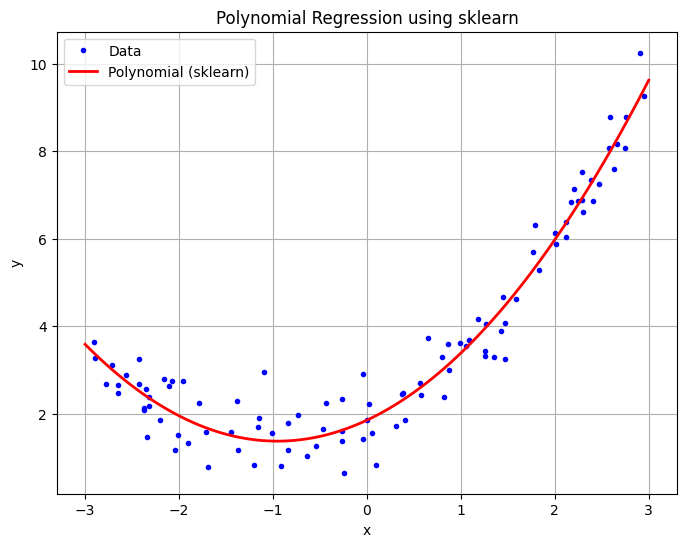

MSE (Polynomial - sklearn): 0.2711


In [10]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 테스트 데이터 변환 및 예측
x_test = np.linspace(-3, 3, 100).reshape(100, 1)
x_poly_test = poly_features.transform(x_test)
y_pred = model_poly.predict(x_poly_test)

# 시각화
plt.figure(figsize=(8, 6))
plt.plot(x, y, "b.", label="Data")
plt.plot(x_test, y_pred, "r-", linewidth=2, label="Polynomial (sklearn)")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression using sklearn')
plt.legend()
plt.grid(True)
plt.show()

# IMPLEMENT HERE: MSE 계산
y_hat = model_poly.predict(x_poly)
mse_test = np.mean((y_hat - y) ** 2)
print(f'MSE (Polynomial - sklearn): {mse_test:.4f}')

---
## 결과 비교

In [11]:
#@title { vertical-output: true}
print("=" * 50)
print("MSE 비교")
print("=" * 50)
print(f"Ground Truth: y = 2 + 1.0x + 0.5x²")
print(f"")
print(f"Linear Regression:       MSE = (Part 2에서 계산)")
print(f"Polynomial (scipy):      MSE = (Part 3에서 계산)")
print(f"Polynomial (sklearn):    MSE = (Part 4에서 계산)")

MSE 비교
Ground Truth: y = 2 + 1.0x + 0.5x²

Linear Regression:       MSE = (Part 2에서 계산)
Polynomial (scipy):      MSE = (Part 3에서 계산)
Polynomial (sklearn):    MSE = (Part 4에서 계산)


---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `polynomial_regression_학번_이름.ipynb`, `polynomial_regression_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---